In [ ]:
from envs import SingleLaneEnv, BasisActionWrapper

import numpy as np
import torch
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import os

%matplotlib inline

: 

In [6]:
def setup(T = 40.0, dt = 0.05, macro_dt = 1.0, K = 10, exp_n=4, last_check = 200000, al=3, alphaV=2):
    env = BasisActionWrapper(
    SingleLaneEnv(T=T, dt=dt, macro_dt=macro_dt, al=al, alphaV=alphaV),
    K=K
    )

    vec_env = DummyVecEnv([lambda: env])

    vec_env = VecNormalize.load(
        os.path.expanduser(f"~/tb_logs/runs/ppo_singlelane_stable_{exp_n}/ppo_ckpt_vecnormalize_{last_check}_steps.pkl"),
        vec_env
    )

    vec_env.training = False
    vec_env.norm_reward = False

    model_path = os.path.expanduser(f"~/tb_logs/runs/ppo_singlelane_stable_{exp_n}/best/best_model")

    model = PPO.load(model_path, env=vec_env)
    return env, vec_env, model

In [7]:
def rollout(env, vec_env, model, det):
    obs = vec_env.reset()

    # if al0:
    #     #Set leader acceleration to zero for testing
    #     base_env = vec_env.venv.envs[0].env
    #     base_env.leading_al = np.zeros(base_env.n_total, dtype=np.float64)

    terminated = False
    truncated = False

    total_reward = 0.0

    done =False

    while not done:
        action, _ = model.predict(obs, deterministic=det)

        obs, reward, done, infos = vec_env.step(action)  # SB3 vec env: returns (obs, rewards, dones, infos)
        total_reward += float(reward[0])

        if done[0]:
            break

        vec_env.venv.envs[0].render()

        env.render()
    print(f"Total reward: {total_reward}")

# Stable 0

In [13]:
env, vec_env, model = setup(T=10.0, dt=0.05, macro_dt=1.0, K=4, exp_n=0, last_check=400000)

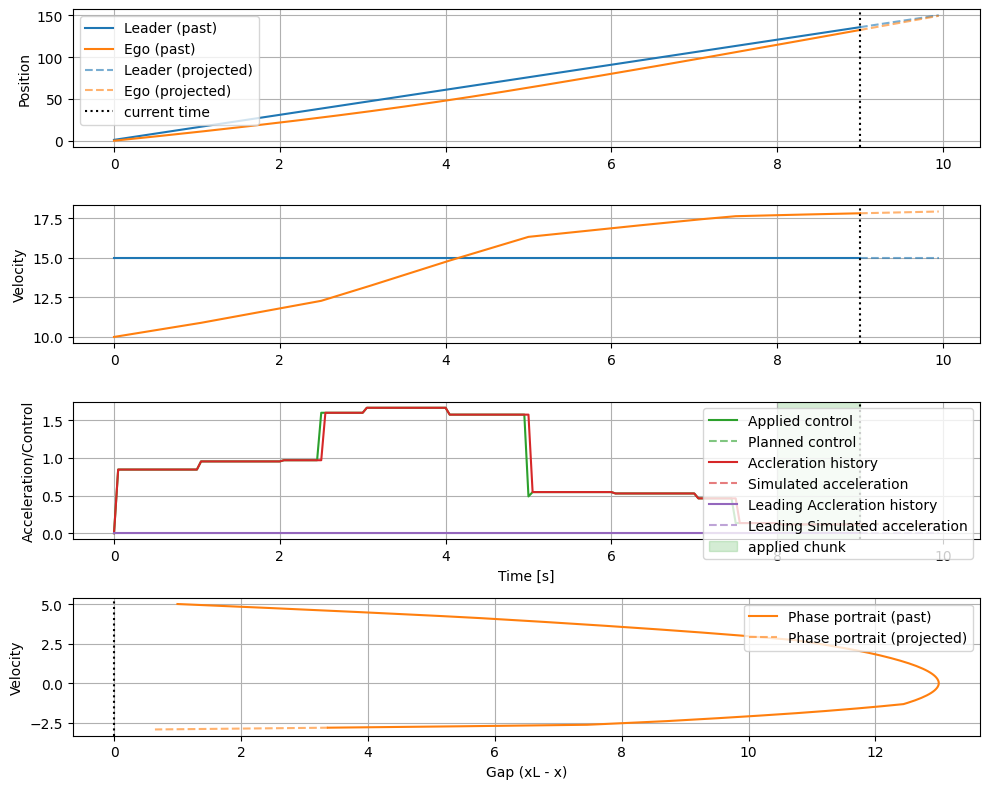

Total reward: 4.722771465778351


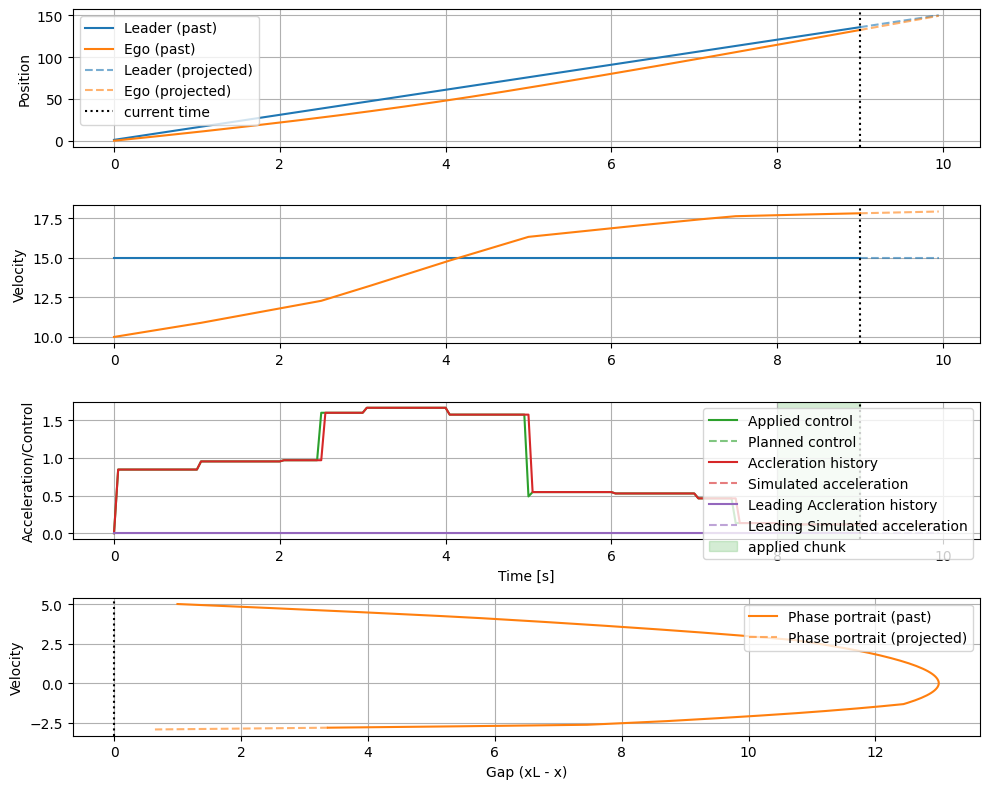

In [14]:
rollout(env, vec_env, model, al0=True)

# Stable 1

In [12]:
env, vec_env, model = setup(T=40.0, dt=0.05, macro_dt=1.0, K=10, exp_n=1, last_check=500000)

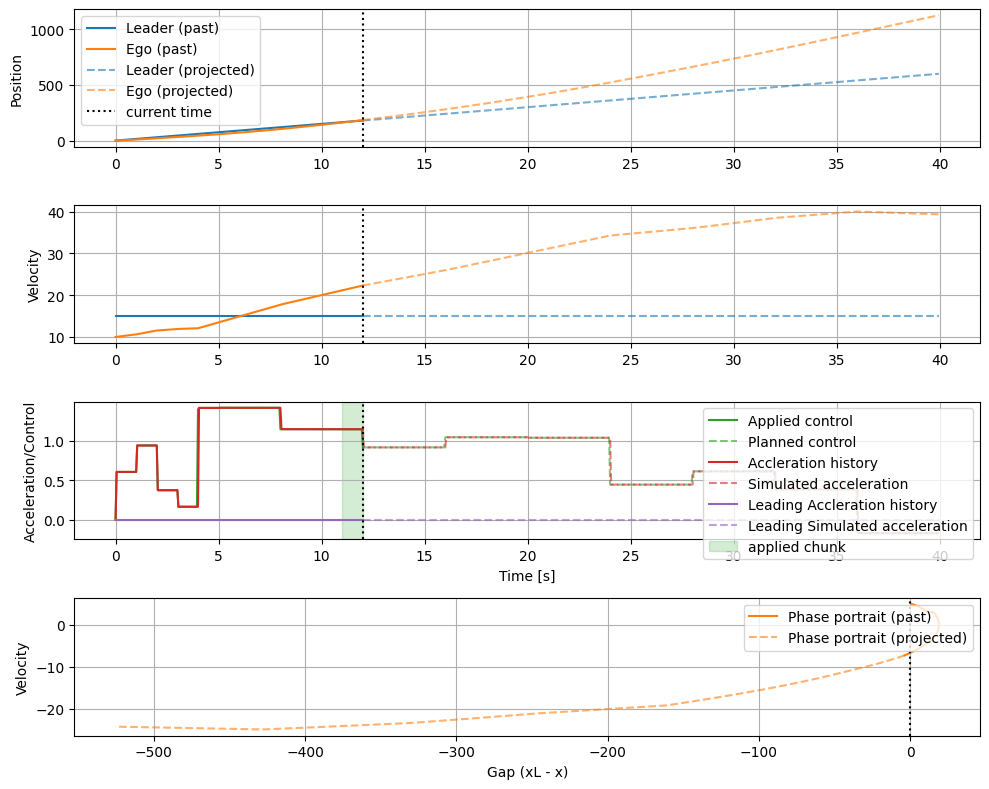

Total reward: -89.64978003501892


In [8]:
rollout(env, vec_env, model, al0=3)

# Stable 2

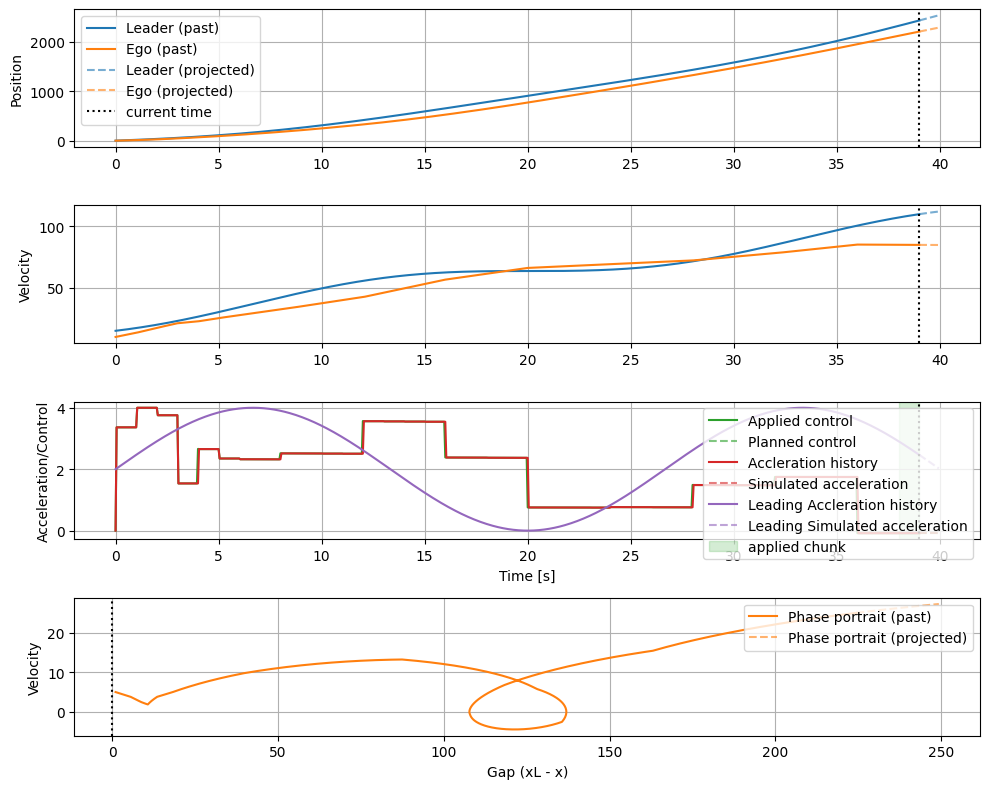

Total reward: 67.65093379095197


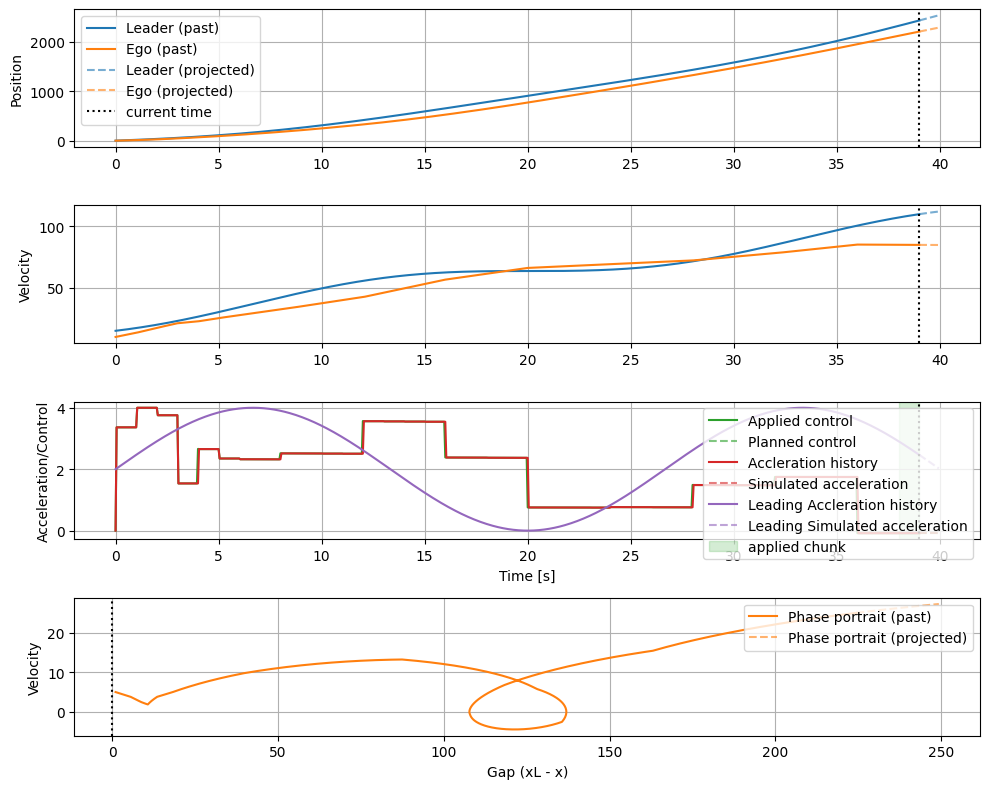

In [18]:
env, vec_env, model = setup(T=40.0, dt=0.05, macro_dt=1.0, K=10, exp_n=2, last_check=500000)
rollout(env, vec_env, model, al0=3)

# Test rewards

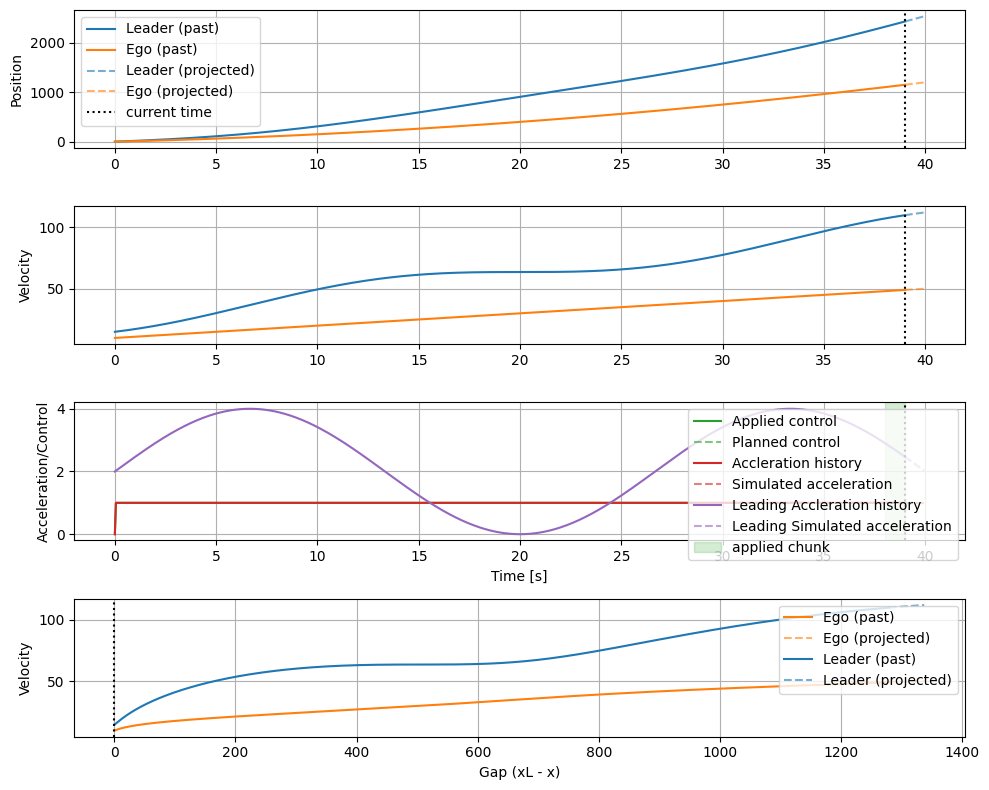

Total reward: 38.66905035096803


In [27]:
obs, _ = env.reset()

action = np.ones(env.action_space.shape, dtype=np.float64)

terminated = False
truncated = False

total_reward = 0.0

while not (terminated or truncated):

    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward

    env.render()

print(f"Total reward: {total_reward}")

# Stable 3

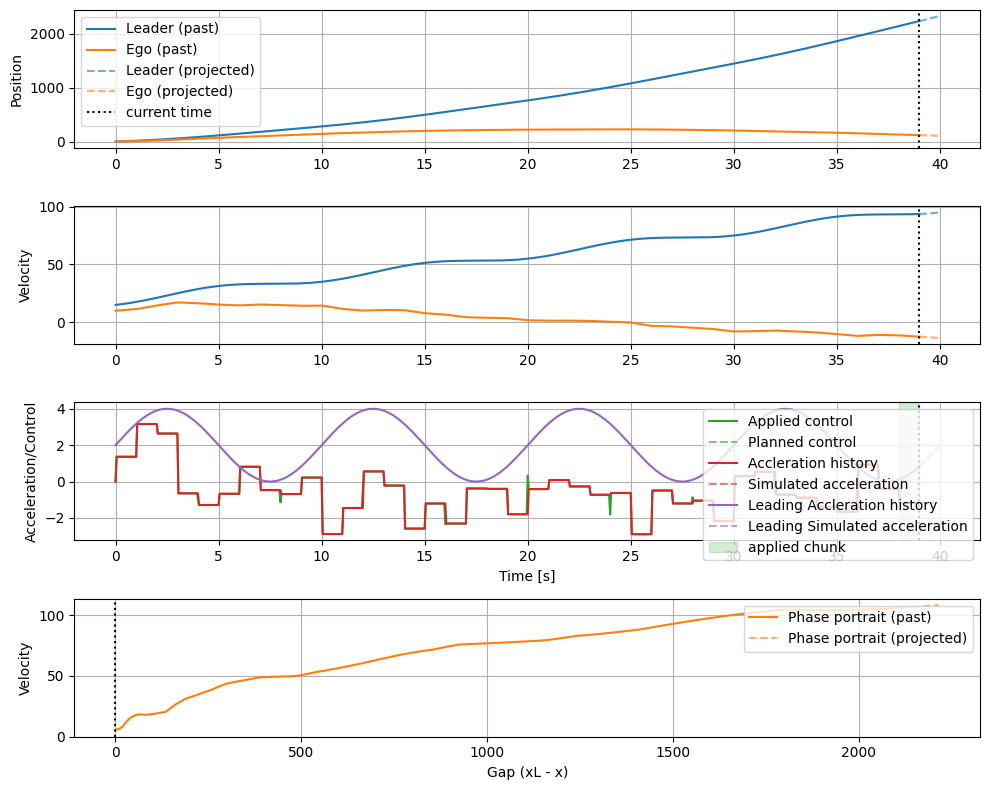

Total reward: 2.0137417218647897


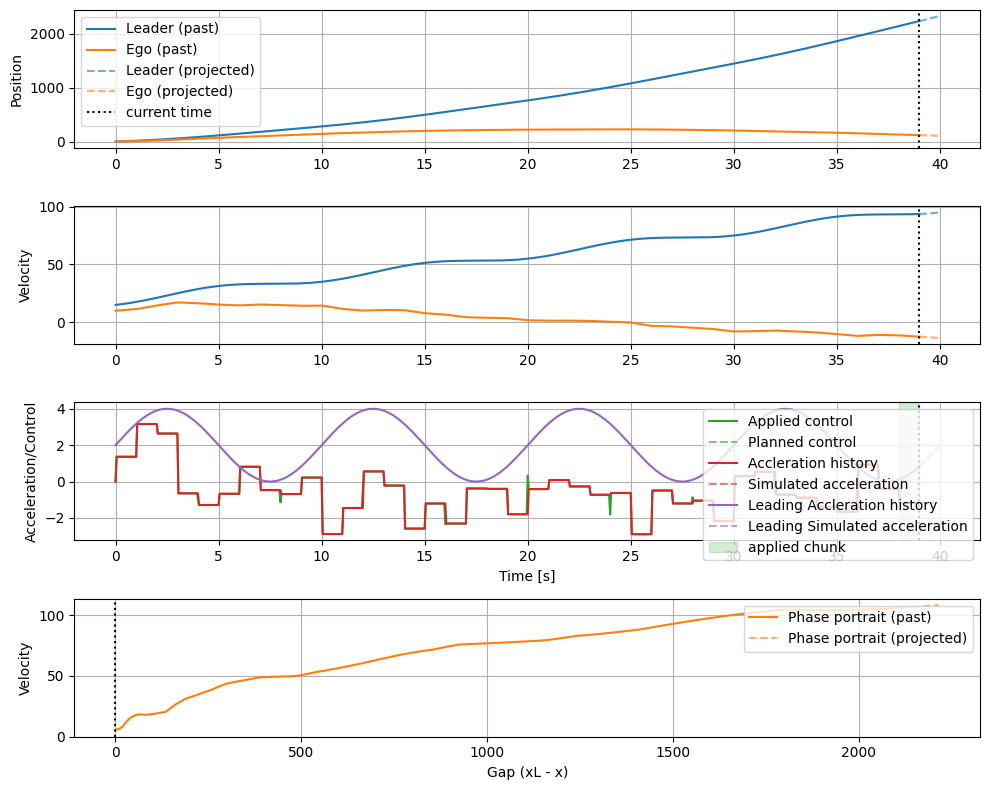

In [20]:
env, vec_env, model = setup(T=40.0, dt=0.05, macro_dt=1.0, K=10, exp_n=3, last_check=400000, al=8)
rollout(env, vec_env, model, al0=8)

# Stable 4

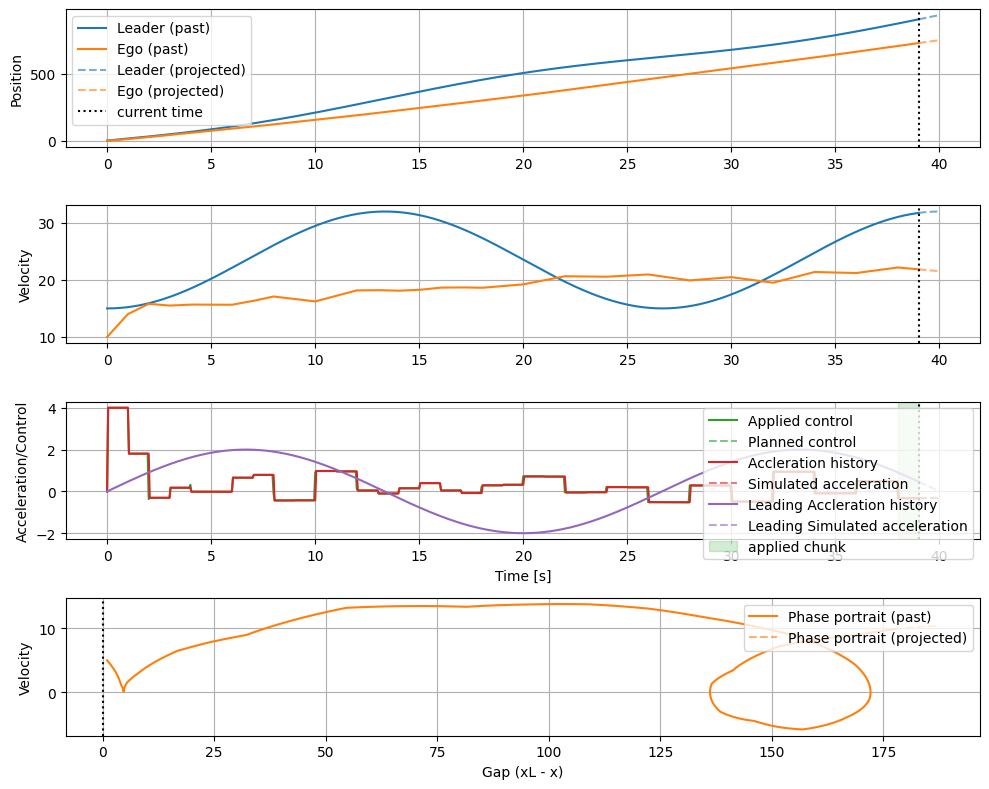

Total reward: 25.082781046628952


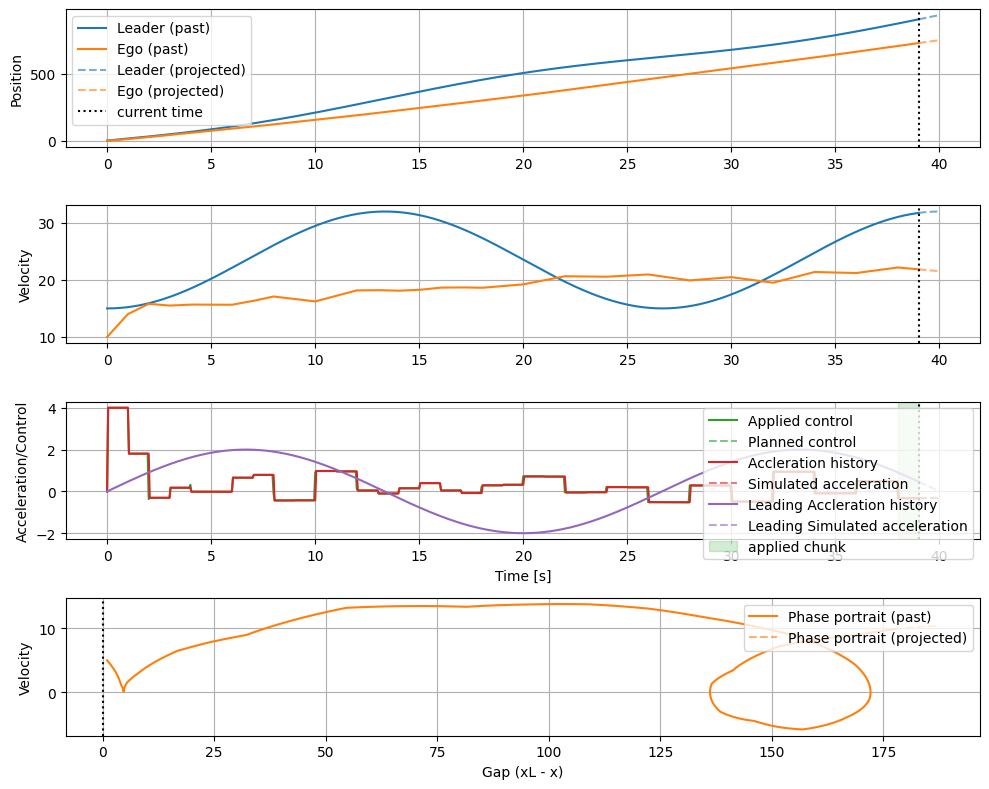

In [9]:
env, vec_env, model = setup(T=40.0, dt=0.05, macro_dt=1.0, K=20, exp_n=4, last_check=400000, al=3)
rollout(env, vec_env, model, det=True)

# Stable 5

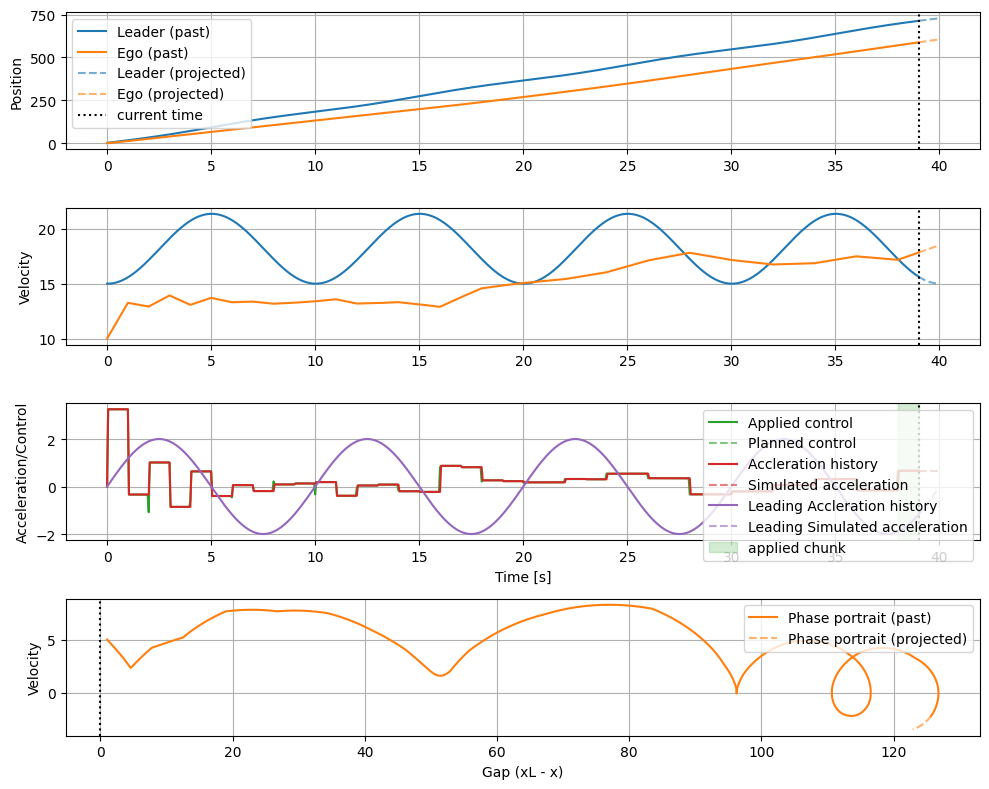

Total reward: 18.486164070665836


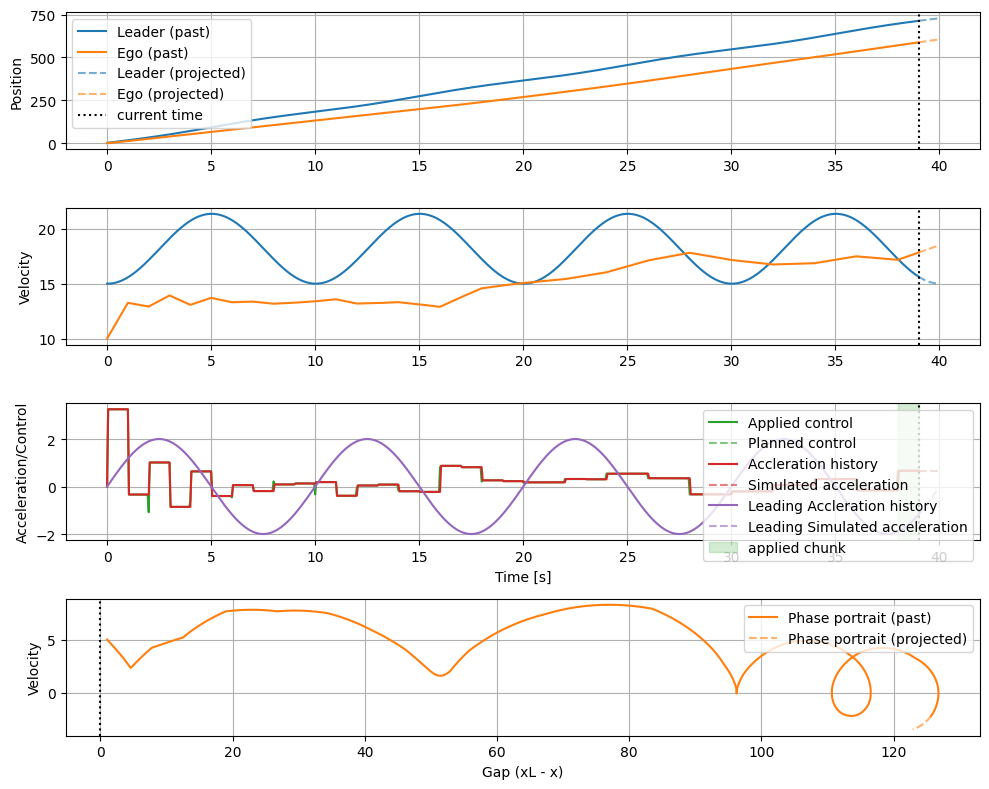

In [9]:
env, vec_env, model = setup(T=40.0, dt=0.05, macro_dt=1.0, K=20, exp_n=5, last_check=450000, al=8, alphaV=0)
rollout(env, vec_env, model, det=True)

# stable 6

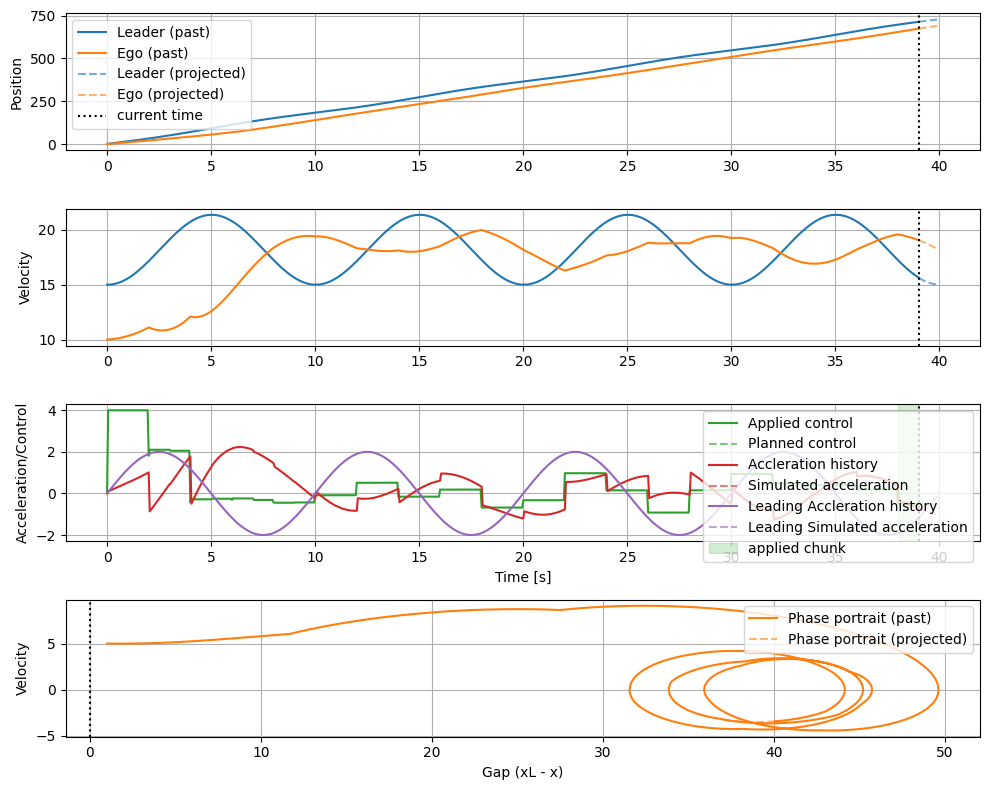

Total reward: 21.384832471609116


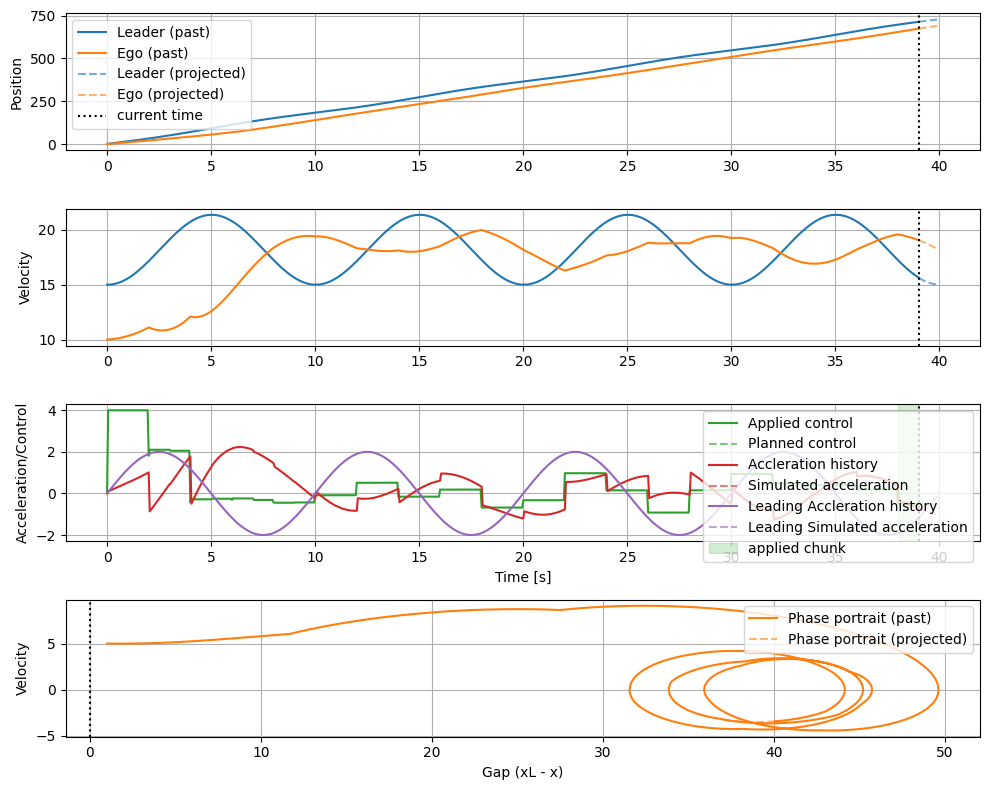

In [10]:
env, vec_env, model = setup(T=40.0, dt=0.05, macro_dt=1.0, K=20, exp_n=6, last_check=350000, al=8, alphaV=0.4)
rollout(env, vec_env, model, det=True)

# Stable 7

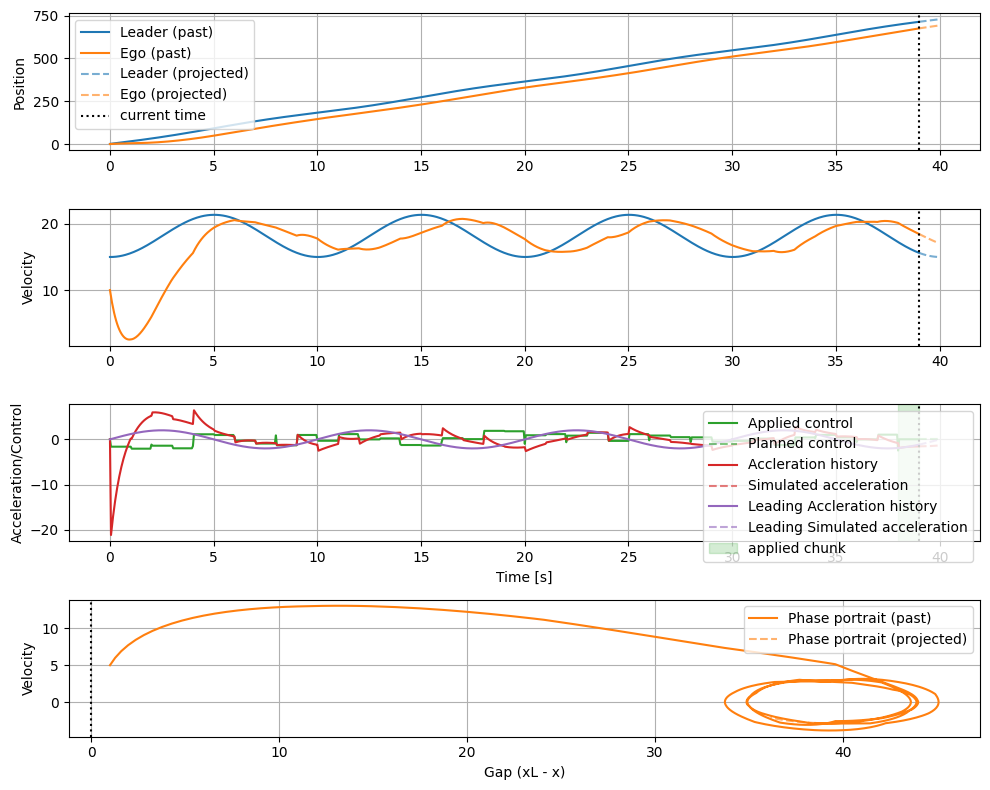

Total reward: 15.230439096689224


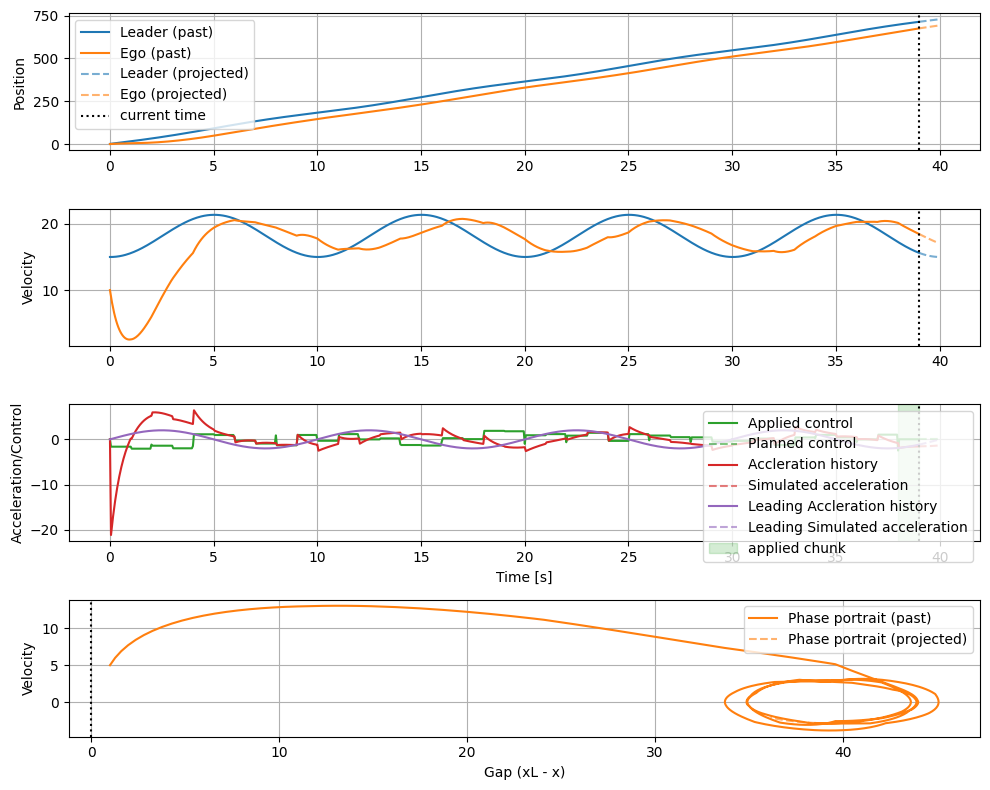

In [5]:
env, vec_env, model = setup(T=40.0, dt=0.05, macro_dt=1.0, K=20, exp_n=7, last_check=500000, al=8)
rollout(env, vec_env, model, det=False)

# Stable 8

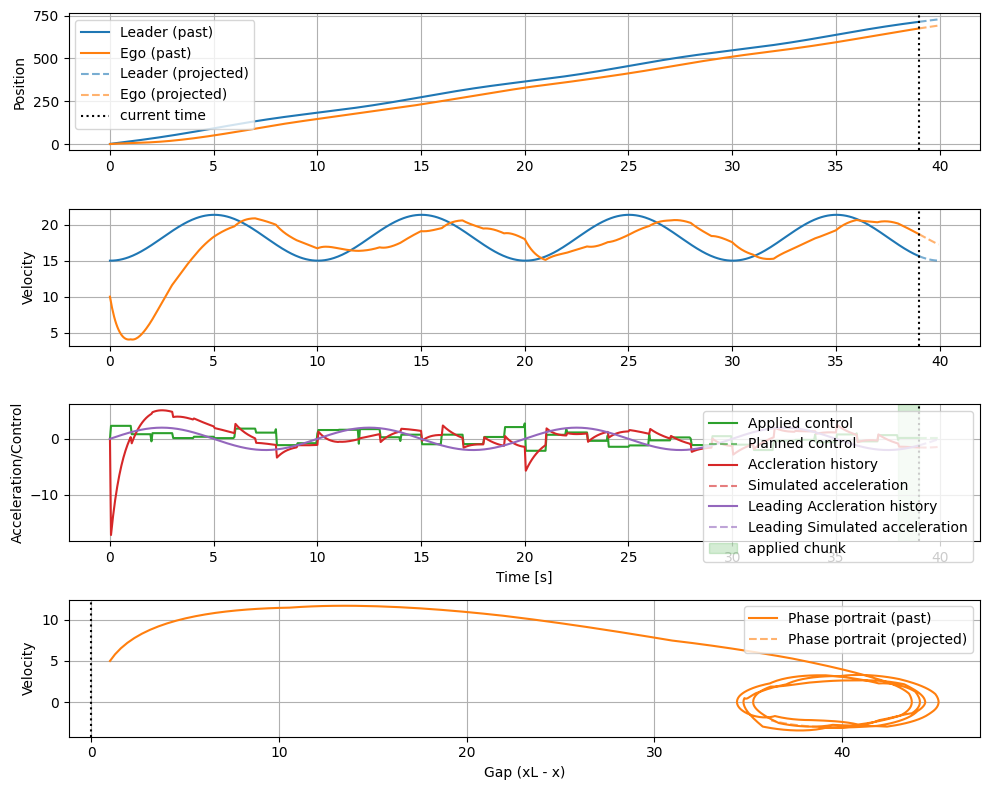

Total reward: 16.91271024942398


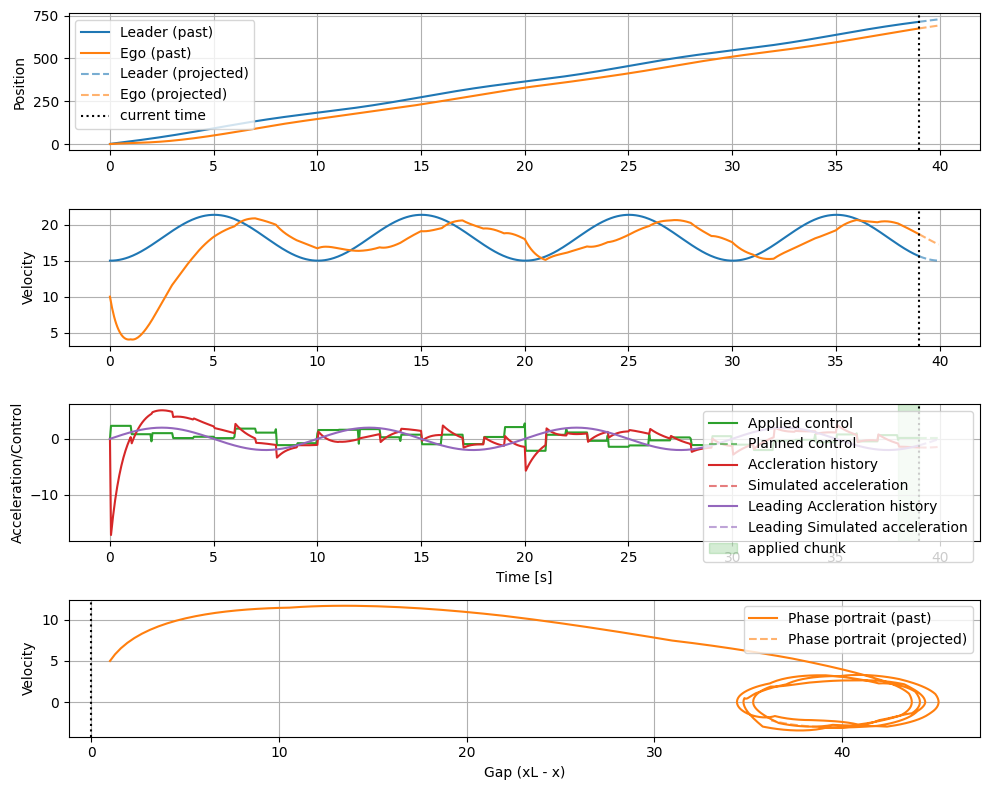

In [11]:
env, vec_env, model = setup(T=40.0, dt=0.05, macro_dt=1.0, K=20, exp_n=8, last_check=500000, al=8, alphaV=2)
rollout(env, vec_env, model, det=False)